# EVASPA Evaporative Fraction generic edge and model

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import xarray as xr

In [3]:
from evaspa.edge import FlatEdge, LinearEdge
from evaspa.ef import EFModel

### Generate test data 

In [ ]:
def setup_data(
    albedo: tuple[float, float],
    dry: tuple[float, float],
    wet: tuple[float, float],
    size: int = 125,
    seed: int = 0,
) -> xr.Dataset:
    """
    Generate data for tests
    """

    def dry_edge(v: npt.ArrayLike) -> npt.NDArray:
        return dry[1] * v + dry[0]

    def wet_edge(v: npt.ArrayLike) -> npt.NDArray:
        return wet[1] * v + wet[0]

    np.random.seed(seed)
    albedo_arr = np.random.uniform(
        low=albedo[0], high=albedo[1], size=(size, size)
    )
    lon = np.linspace(start=1.0, stop=2.0, num=size, dtype=np.float32)
    lat = np.linspace(start=43.0, stop=44.0, num=size, dtype=np.float32)
    lst_func = np.vectorize(
        lambda x: np.random.uniform(wet_edge(x), dry_edge(x))
    )
    lst_arr = lst_func(albedo_arr)
    valid_arr = np.random.choice([0, 1], size=(size, size), p=[0.2, 0.8])
    ef_arr = (dry_edge(albedo_arr) - lst_arr) / (
        dry_edge(albedo_arr) - wet_edge(albedo_arr)
    )
    return xr.Dataset(
        data_vars={
            "albedo": (["lon", "lat"], albedo_arr),
            "lst": (["lon", "lat"], lst_arr),
            "valid": (["lon", "lat"], valid_arr),
            "ef": (["lon", "lat"], ef_arr),
        },
        coords={
            "lon": ("lon", lon),
            "lat": ("lat", lat),
        },
        attrs={"description": "Test data"},
    )

In [ ]:
# Generate data
data = setup_data(albedo=(0.0, 0.6), dry=(330.0, -13.0), wet=(300.0, 30.0))

In [6]:
data

<xarray.Dataset> Size: 501kB
Dimensions:  (lon: 125, lat: 125)
Coordinates:
  * lon      (lon) float32 500B 1.0 1.008 1.016 1.024 ... 1.976 1.984 1.992 2.0
  * lat      (lat) float32 500B 43.0 43.01 43.02 43.02 ... 43.98 43.99 44.0
Data variables:
    albedo   (lon, lat) float64 125kB 0.3293 0.4291 0.3617 ... 0.2626 0.3877
    lst      (lon, lat) float64 125kB 324.2 314.0 316.8 ... 318.9 309.5 321.2
    valid    (lon, lat) int64 125kB 1 1 0 1 1 1 1 1 1 1 ... 0 1 1 1 1 1 1 1 1 1
    ef       (lon, lat) float64 125kB 0.09642 0.9004 0.59 ... 0.9157 0.2817
Attributes:
    description:  Test data

In [ ]:
def plot(data: xr.Dataset, model: EFModel = None, save: bool = False):
    """
    Plot
    """
    # dimensions
    # gridspec inside gridspec
    fig = plt.figure(constrained_layout=True, figsize=(4, 3))

    ax = plt.gca()

    var = data["albedo"].data
    lst = data["lst"].data

    # plot all points
    ax.scatter(var, lst, s=20, alpha=1, color="moccasin", clip_on=False)

    # plot edges
    if model is not None:
        # edges coordinates
        var_max = np.round(np.ceil(np.nanmax(var) * 10) / 10, decimals=1)
        var_min = np.round(np.floor(np.nanmin(var) * 10) / 10, decimals=1)

        var_arr = np.linspace(var_min, var_max, num=20)
        tw_arr = model.twet(var_arr)
        td_arr = model.tdry(var_arr)

        ax.plot(
            var_arr,
            td_arr,
            color="tab:red",
            linewidth=3,
            label="dry edge",
            zorder=1,
        )
        ax.plot(
            var_arr,
            tw_arr,
            color="tab:blue",
            linewidth=3,
            label="wet edge",
            zorder=1,
        )

    # Labels
    ax.set_xlabel("Variable")
    ax.set_ylabel("Land Surface Temperature K")

    # title
    ax.set_title("Evaporative fraction method", fontsize=12)

    # savefig
    if save:
        destfile = "ef.png"
        fig.savefig(destfile)

    plt.show()

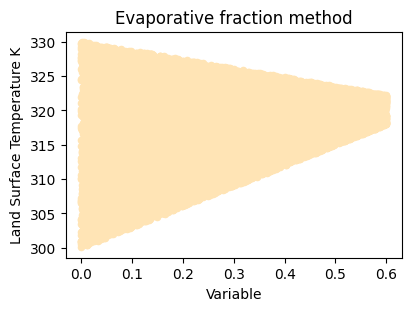

In [8]:
plot(data)

## Edge definition

In [9]:
config1 = '{"interval_type":"size","interval_nb":20,"percentile":[98,100],"selection":"max"}'

In [10]:
edge1 = LinearEdge.model_validate_json(config1)

In [ ]:
edge1.fit(data["albedo"], data["lst"])

In [12]:
edge1

LinearEdge(percentile=(98, 100),interval_type=size,interval_nb=20,selection=max,coeffs=(np.float64(-12.895262176710972), np.float64(330.0439881096859)))

In [ ]:
edge2 = FlatEdge.model_validate_json('{"selection":"max"}')

In [ ]:
edge2.fit(data["albedo"], data["lst"])

In [15]:
edge2

FlatEdge(selection=<SelectionFlatMethod.MAX: 'max'>, value=np.float64(329.9655664565513))

In [16]:
edge3 = FlatEdge.model_validate_json('{"selection":"min"}')
edge3.fit(data["albedo"], data["lst"])
edge3

FlatEdge(selection=<SelectionFlatMethod.MIN: 'min'>, value=np.float64(300.0405887147721))

## EF model definition

In [ ]:
config_model1 = {
    "name": "model1",
    "dry_edge": {
        "type": "LinearEdge",
        "config": {
            "interval_type": "size",
            "interval_nb": 20,
            "percentile": [98, 100],
            "selection": "median",
        },
    },
    "wet_edge": {
        "type": "LinearEdge",
        "config": {
            "interval_type": "size",
            "interval_nb": 20,
            "percentile": [0, 2],
            "selection": "median",
        },
    },
    "var": "albedo",
}

In [ ]:
model1 = EFModel.create(config_model1)

In [19]:
model1.fit(data)

In [ ]:
model1.fit(data, mask="valid")

In [21]:
model1.compute(data)

<xarray.DataArray (lon: 125, lat: 125)> Size: 125kB
array([[0.08723781, 0.90022343, 0.58784498, ..., 0.34571005, 0.62161768,
        0.13294113],
       [0.12489582, 0.51647785, 0.20884717, ..., 0.69461831, 0.72580687,
        0.45686015],
       [0.94104141, 0.16119755, 0.5274528 , ..., 0.05625503, 0.66570164,
        0.60565421],
       ...,
       [0.51277491, 0.86484552, 0.57053591, ..., 0.33286118, 0.32945216,
        0.74362742],
       [0.53422752, 0.84944546, 0.56734735, ..., 0.36063448, 0.4036008 ,
        0.45421277],
       [0.30005796, 0.56769966, 0.2875077 , ..., 0.38096738, 0.92090012,
        0.27459532]], shape=(125, 125))
Coordinates:
  * lon      (lon) float32 500B 1.0 1.008 1.016 1.024 ... 1.976 1.984 1.992 2.0
  * lat      (lat) float32 500B 43.0 43.01 43.02 43.02 ... 43.98 43.99 44.0
Attributes:
    name:      model1
    dry_edge:  {'type': 'LinearEdge', 'config': {'percentile': (98, 100), 'in...
    wet_edge:  {'type': 'LinearEdge', 'config': {'percentile': (0, 2), 'inter...
    var:       albedo

In [ ]:
model1.compute(data, mask="valid")

<xarray.DataArray (lon: 125, lat: 125)> Size: 125kB
array([[0.08723781, 0.90022343,        nan, ..., 0.34571005, 0.62161768,
        0.13294113],
       [       nan, 0.51647785, 0.20884717, ..., 0.69461831, 0.72580687,
        0.45686015],
       [0.94104141,        nan, 0.5274528 , ...,        nan,        nan,
        0.60565421],
       ...,
       [0.51277491, 0.86484552, 0.57053591, ..., 0.33286118,        nan,
        0.74362742],
       [0.53422752,        nan, 0.56734735, ..., 0.36063448, 0.4036008 ,
        0.45421277],
       [       nan, 0.56769966, 0.2875077 , ..., 0.38096738, 0.92090012,
        0.27459532]], shape=(125, 125))
Coordinates:
  * lon      (lon) float32 500B 1.0 1.008 1.016 1.024 ... 1.976 1.984 1.992 2.0
  * lat      (lat) float32 500B 43.0 43.01 43.02 43.02 ... 43.98 43.99 44.0
Attributes:
    name:      model1
    dry_edge:  {'type': 'LinearEdge', 'config': {'percentile': (98, 100), 'in...
    wet_edge:  {'type': 'LinearEdge', 'config': {'percentile': (0, 2), 'inter...
    var:       albedo

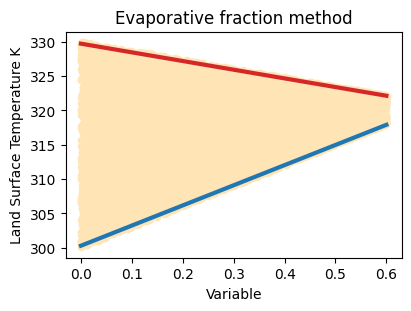

In [ ]:
plot(data, model=model1)

In [24]:
print(model1)

Model(model1,dry_edge=<class 'evaspa.edge.LinearEdge'>,wet_edge=<class 'evaspa.edge.LinearEdge'>,var=albedo)


In [25]:
model1

Model: model1
 - dry edge = LinearEdge(percentile=(98, 100),interval_type=size,interval_nb=20,selection=median,coeffs=(np.float64(-12.641634907370182), np.float64(329.7151657601132)))
 - wet edge = LinearEdge(percentile=(0, 2),interval_type=size,interval_nb=20,selection=median,coeffs=(np.float64(29.34513068542796), np.float64(300.2930034630033)))
 - var = albedo

In [26]:
model1.to_dict()

{'name': 'model1',
 'dry_edge': {'type': 'LinearEdge',
  'config': {'percentile': (98, 100),
   'interval_type': 'size',
   'interval_nb': 20,
   'selection': 'median',
   'coeffs': (np.float64(-12.641634907370182),
    np.float64(329.7151657601132))}},
 'wet_edge': {'type': 'LinearEdge',
  'config': {'percentile': (0, 2),
   'interval_type': 'size',
   'interval_nb': 20,
   'selection': 'median',
   'coeffs': (np.float64(29.34513068542796), np.float64(300.2930034630033))}},
 'var': 'albedo'}